In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, roc_curve, classification_report,
    precision_recall_curve, average_precision_score
)

In [74]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 
    'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]
df = pd.read_csv(url, names=columns, na_values="?")
df = df.astype(float).fillna(df.median())
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [76]:
X, y = df.drop('target', axis=1), df['target']
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, stratify=y, random_state=42)

In [78]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [80]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [82]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")


Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.85      0.88        41
           1       0.84      0.89      0.86        35

    accuracy                           0.87        76
   macro avg       0.87      0.87      0.87        76
weighted avg       0.87      0.87      0.87        76

ROC AUC Score: 0.9310


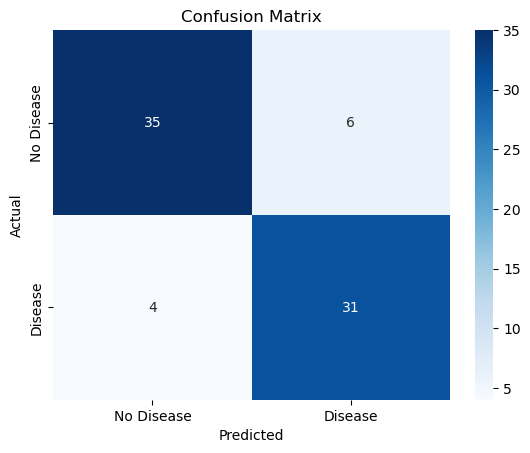

In [84]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

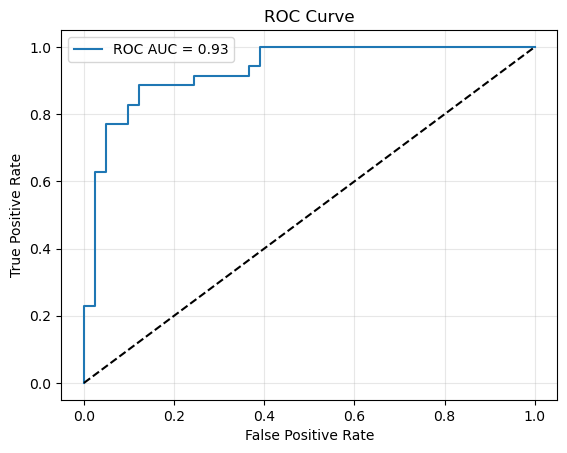

In [86]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

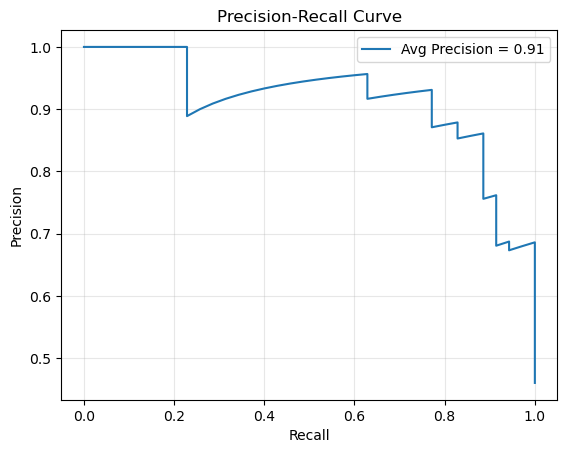

In [88]:
precisions, recalls, _ = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)
plt.plot(recalls, precisions, label=f"Avg Precision = {avg_precision:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [92]:
coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_[0]}).sort_values(by="Coefficient", key=np.abs, ascending=False)
print("\nTop Influential Features:\n", coef_df.head(5))


Top Influential Features:
     Feature  Coefficient
11       ca     1.144624
12     thal     0.676373
1       sex     0.637370
2        cp     0.574812
7   thalach    -0.347604


In [94]:
thresholds = np.arange(0.3, 0.8, 0.1)
metrics = []
for t in thresholds:
    pred_t = (y_proba >= t).astype(int)
    metrics.append({
        "Threshold": t,
        "Accuracy": accuracy_score(y_test, pred_t),
        "Precision": precision_score(y_test, pred_t),
        "Recall": recall_score(y_test, pred_t),
        "F1": f1_score(y_test, pred_t)
    })

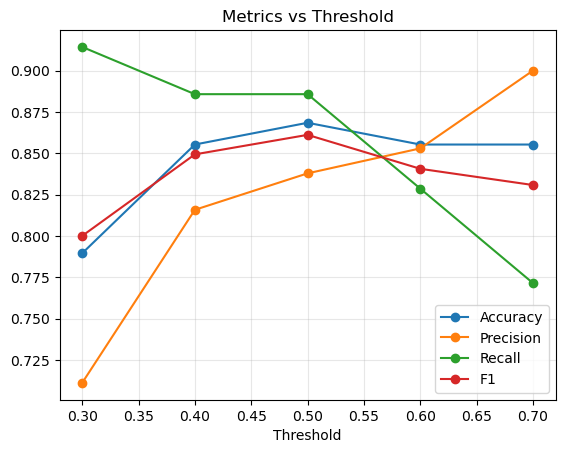

In [96]:
metrics_df = pd.DataFrame(metrics)
metrics_df.plot(x='Threshold', marker='o')
plt.title("Metrics vs Threshold")
plt.grid(alpha=0.3)
plt.show()

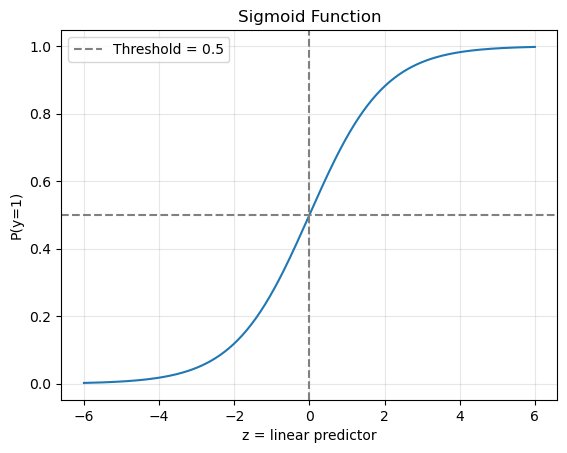

In [98]:
def sigmoid(z): return 1 / (1 + np.exp(-z))
z = np.linspace(-6, 6, 200)
plt.plot(z, sigmoid(z))
plt.axhline(0.5, color='gray', linestyle='--', label='Threshold = 0.5')
plt.axvline(0, color='gray', linestyle='--')
plt.title("Sigmoid Function")
plt.xlabel("z = linear predictor")
plt.ylabel("P(y=1)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()